In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import torch
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.stats import skew, spearmanr
import shap
from sklearn.feature_selection import RFE
from collections import Counter

from sklearn.model_selection import train_test_split, KFold, LeavePGroupsOut, LeaveOneGroupOut, LeaveOneOut
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import make_pipeline

from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from tabpfn import TabPFNRegressor
from lightgbm import LGBMRegressor
import lightgbm

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

Choosing the Estimator
The choice of the estimator within RFE is significant because the feature importance ranking depends entirely on it.

* Linear Models: Estimators like LinearRegression, LogisticRegression, or LinearSVC use coefficient magnitudes (coef_) to rank features. Features with larger absolute coefficients are considered more important. Regularization (like L1 or L2) within these models can influence the coefficients and thus the ranking.

* Tree-Based Models: Estimators like DecisionTreeClassifier, RandomForestClassifier, or GradientBoostingClassifier use the feature_importances_ attribute, which typically measures how much each feature contributes to reducing impurity (like Gini impurity or entropy) across all trees in the forest or ensemble.

https://apxml.com/courses/intro-feature-engineering/chapter-6-feature-selection/wrapper-rfe

In [2]:
seed = 69
np.random.seed(seed)
torch.manual_seed(seed)

In [3]:
data = pd.read_csv('./new_dataset/maison-llf-features.CSV', sep=",")

display(data)

,participant,timestamp,clinical-timestamp,sis-01,sis-02,sis-03,sis-04,sis-05,sis-06,sis,...,sleep-duration-to-wakeup,sleep-wakeup-count,sleep-heartrate-mean,sleep-heartrate-min,sleep-heartrate-max,step-count,step-ratio,step-mean,step-max,step-max-timestamp
0,1,2022-03-31,2022-04-13,5,5,4,4,5,2,25,...,0.0000,3,59,54,74,415,0.5000,34.5833,106,13
1,1,2022-04-01,2022-04-13,5,5,4,4,5,2,25,...,0.0000,4,61,56,82,447,0.2917,63.8571,185,8
2,1,2022-04-02,2022-04-13,5,5,4,4,5,2,25,...,0.1700,3,59,55,83,533,0.4231,56.1132,170,14
3,1,2022-04-03,2022-04-13,5,5,4,4,5,2,25,...,0.0000,1,59,54,72,530,0.2083,106.0000,288,22
4,1,2022-04-04,2022-04-13,5,5,4,4,5,2,25,...,0.0000,2,61,56,73,686,0.3750,76.2222,176,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1003,18,2025-10-25,2025-10-29,5,5,5,5,5,5,30,...,0.1833,1,50,41,60,2018,0.4583,183.4545,370,8
1004,18,2025-10-26,2025-10-29,5,5,5,5,5,5,30,...,0.1833,7,46,41,59,5234,0.4583,475.8182,3052,14
1005,18,2025-10-27,2025-10-29,5,5,5,5,5,5,30,...,0.1833,7,49,39,70,783,0.2917,111.8571,367,17
1006,18,2025-10-28,2025-10-29,5,5,5,5,5,5,30,...,0.1833,10,51,41,74,4666,0.3531,741.5590,2061,15


In [4]:
#display(data.columns.to_list())

In [5]:
acceleration    = data.filter(like='acceleration').columns.tolist()
heartrate       = data.filter(like='heartrate').filter(regex='^(?!.*sleep)').columns.tolist()
motion          = data.filter(like='motion').columns.tolist()
position        = data.filter(like='position').columns.tolist()
sleep           = data.filter(like='sleep').columns.tolist()
step            = data.filter(like='step').columns.tolist()
demographics    = ['sex', 'age']



#display(acceleration)
#display(heartrate)
#display(motion)
#display(position)
#display(sleep)
display(step)

['step-count', 'step-ratio', 'step-mean', 'step-max', 'step-max-timestamp']

In [6]:
modalities = acceleration + heartrate + motion + position + sleep + step
sensor = data[modalities]

sis = data['sis']
participant = data['participant']

x = np.array(sensor)
y = np.array(sis)
p = np.array(participant)

feature_names = sensor.columns.to_list()

In [7]:
display(x.shape, y.shape, p.shape, len(feature_names), feature_names)

(1008, 46)

(1008,)

(1008,)

46

['acceleration-count',
 'acceleration-mean',
 'acceleration-std',
 'acceleration-sum',
 'acceleration-entropy',
 'acceleration-kurtosis',
 'acceleration-skew',
 'acceleration-coefficient-of-variation',
 'acceleration-minutes-with-data',
 'acceleration-hours-with-data',
 'acceleration-movement-events-00to06',
 'acceleration-movement-events-06to12',
 'acceleration-movement-events-12to18',
 'acceleration-movement-events-18to24',
 'acceleration-movement-events-24h',
 'acceleration-intradaily-variability',
 'heartrate-count',
 'heartrate-min',
 'heartrate-max',
 'heartrate-mean',
 'heartrate-std',
 'heartrate-hours-with-data',
 'motion-count',
 'motion-ratio',
 'motion-mean',
 'motion-max',
 'motion-max-timestamp',
 'position-count',
 'position-duration',
 'position-distance-travelled',
 'sleep-total',
 'sleep-deep',
 'sleep-light',
 'sleep-rem',
 'sleep-snoring',
 'sleep-duration-to-sleep',
 'sleep-duration-to-wakeup',
 'sleep-wakeup-count',
 'sleep-heartrate-mean',
 'sleep-heartrate-min',

In [8]:
Y_TRUES = np.empty([0])
Y_PREDS = np.empty([0])
SHAP = []
X_TEST = []

cv = KFold(n_splits=5, shuffle=True, random_state=seed)

In [9]:
for fold, (train_idx, test_idx) in enumerate(cv.split(x), start=1):
    
    print(f"Fold {fold}: train={len(train_idx)} test={len(test_idx)}")

    x_train, x_test = x[train_idx], x[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    scaler = StandardScaler()
    x_train = scaler.fit_transform(x_train)
    x_test = scaler.transform(x_test)

    normalizer = MinMaxScaler()
    x_train = normalizer.fit_transform(x_train)
    x_test = normalizer.transform(x_test)

    model = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.1,
        depth=3,
        loss_function='RMSE',
        verbose=False
    )

    model.fit(x_train, y_train, eval_set=(x_train, y_train), use_best_model=True, early_stopping_rounds=100)
    y_preds = model.predict(x_test)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(x_test)

    SHAP.append(shap_values)
    X_TEST.append(x_test)

    Y_TRUES = np.append(Y_TRUES, y_test)
    Y_PREDS = np.append(Y_PREDS, y_preds)

Fold 1: train=806 test=202
Fold 2: train=806 test=202
Fold 3: train=806 test=202
Fold 4: train=807 test=201
Fold 5: train=807 test=201


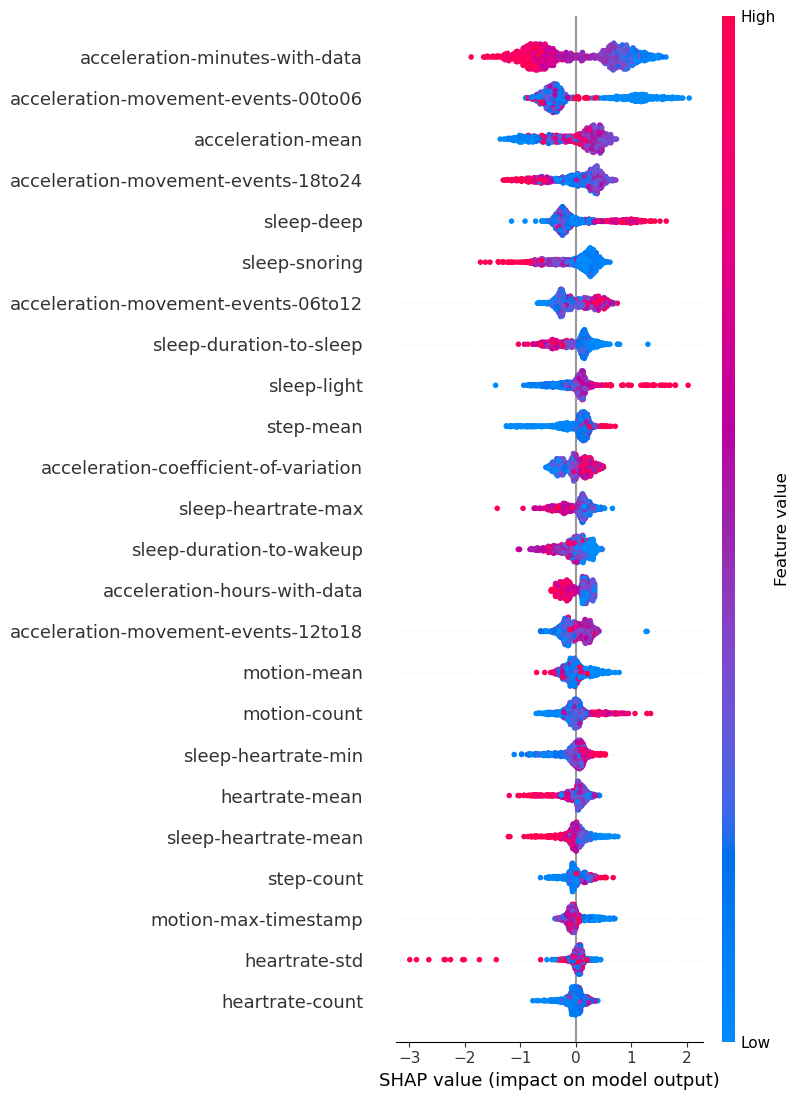

In [10]:
shap_df = pd.DataFrame({
    'feature': modalities,
    'mean_abs_shap': np.abs(np.vstack(SHAP)).mean(axis=0).round(4)
}).sort_values(by='mean_abs_shap', ascending=False)
# display(shap_df)
shap.summary_plot(np.vstack(SHAP), pd.DataFrame(np.vstack(X_TEST), columns=modalities), max_display=24)

In [11]:
# Select the first num_features features based on SHAP importance + demographics
num_features = 16
x = np.array(data[
    shap_df['feature'].iloc[:num_features].to_list()
    # + demographics
    ])

# CatBoost

In [12]:
# CatBoost

Y_TRUES = np.empty([0])
Y_PREDS = np.empty([0])

# cv = LeaveOneOut()
# for fold, (train_idx, test_idx) in enumerate(cv.split(x), start=1):

# cv = LeaveOneGroupOut()
# for fold, (train_idx, test_idx) in enumerate(cv.split(x, y, groups=p), start=1):


In [13]:
cv = KFold(n_splits=5, shuffle=True, random_state=seed)
for fold, (train_idx, test_idx) in enumerate(cv.split(x), start=1):

    print(f"Fold {fold}: train={len(train_idx)} test={len(test_idx)}")

    x_train, x_test = x[train_idx], x[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]


    scaler = StandardScaler()
    x_train = scaler.fit_transform(x_train)
    x_test = scaler.transform(x_test)

    normalizer = MinMaxScaler()
    x_train = normalizer.fit_transform(x_train)
    x_test = normalizer.transform(x_test)

    # ----- CatBoost
    model = CatBoostRegressor(
        iterations=1000,
        learning_rate=.1,
        depth=3,
        loss_function='RMSE',
        verbose=False
    )
    
    model.fit(x_train, y_train,
              eval_set=(x_train, y_train),
            #   eval_set=(x_test, y_test),              
              use_best_model=True, early_stopping_rounds=100)
    
    y_preds = model.predict(x_test)

    Y_TRUES = np.append(Y_TRUES, y_test)
    Y_PREDS = np.append(Y_PREDS, y_preds)

Fold 1: train=806 test=202
Fold 2: train=806 test=202
Fold 3: train=806 test=202
Fold 4: train=807 test=201
Fold 5: train=807 test=201


In [14]:
indx = Y_TRUES.argsort()
Y_TRUES = Y_TRUES[indx]
Y_PREDS = Y_PREDS[indx]

mae = mean_absolute_error(Y_TRUES, Y_PREDS)
mse = mean_squared_error(Y_TRUES, Y_PREDS)
r2 = r2_score(Y_TRUES, Y_PREDS)
corr, _ = spearmanr(Y_TRUES, Y_PREDS)

results = {
    'mae': f"{mae:.4f}",
    'mse': f"{mse:.4f}",
    'r2_score': f"{r2:.4f}",
    'correlation': f"{corr:.4f}"
}

results = pd.DataFrame([results])
display(results.style.hide(axis='index'))

mae,mse,r2_score,correlation
1.4910,4.1159,0.7201,0.8717


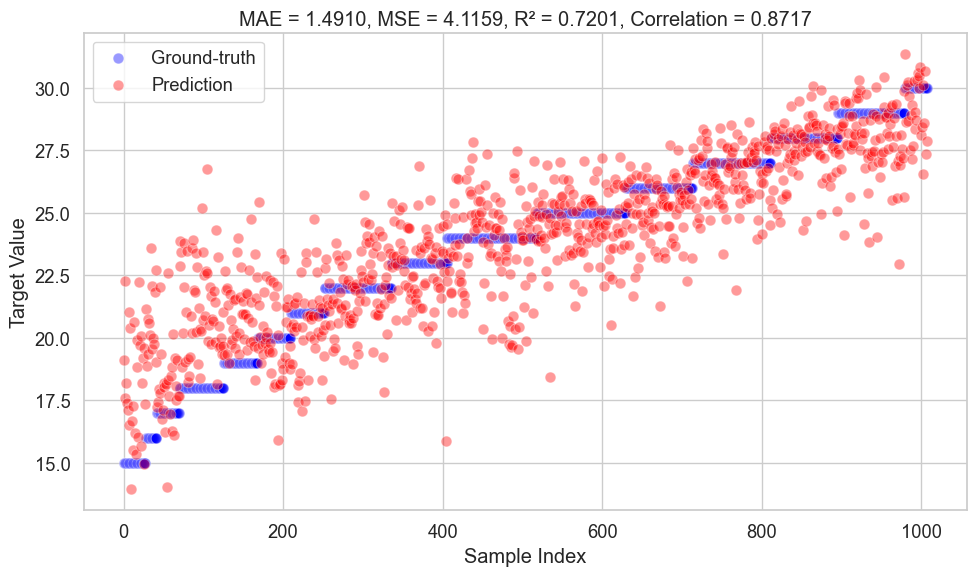

In [15]:
sns.set(style="whitegrid", font_scale=1.2)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=range(len(Y_TRUES)), y=Y_TRUES, label='Ground-truth', color='blue', alpha=0.4, s=60)
sns.scatterplot(x=range(len(Y_PREDS)), y=Y_PREDS, label='Prediction', color='red', alpha=0.4, s=60)

plt.xlabel('Sample Index')
plt.ylabel('Target Value')
plt.title(f"MAE = {mae:.4f}, MSE = {mse:.4f}, R² = {r2:.4f}, Correlation = {corr:.4f}")
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# CatBoost - RFE

In [16]:
# CatBoost - RFE

x = np.array(sensor)
y = np.array(sis)
p = np.array(participant)

feature_names = sensor.columns.to_list()
# + ['sex', 'age']

selected_features_all_folds = []

Y_TRUES = np.empty([0])
Y_PREDS = np.empty([0])


# cv = LeaveOneOut()
# for fold, (train_idx, test_idx) in enumerate(cv.split(x), start=1):

# cv = LeaveOneGroupOut()
# for fold, (train_idx, test_idx) in enumerate(cv.split(x, y, groups=p), start=1):


In [17]:
cv = KFold(n_splits=5, shuffle=True, random_state=seed)
for fold, (train_idx, test_idx) in enumerate(cv.split(x), start=1):
    


    print(f"Fold {fold}: train={len(train_idx)} test={len(test_idx)}")

    x_train, x_test = x[train_idx], x[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]


    scaler = StandardScaler()
    x_train = scaler.fit_transform(x_train)
    x_test = scaler.transform(x_test)

    normalizer = MinMaxScaler()
    x_train = normalizer.fit_transform(x_train)
    x_test = normalizer.transform(x_test)


    # RFE
    num_features = 24
    model_for_rfe = CatBoostRegressor(
        iterations=1000,
        learning_rate=.1,
        depth=3,
        loss_function='RMSE',
        verbose=False
    )
    rfe = RFE(estimator=model_for_rfe, n_features_to_select=num_features, step=1)
    rfe.fit(x_train, y_train)

    selected_indices = rfe.get_support(indices=True)
    selected_feature_names = [feature_names[i] for i in selected_indices]
    print(f"Fold {fold} selected features: {selected_feature_names}")
    selected_features_all_folds.extend(selected_feature_names)


    x_train = rfe.transform(x_train)
    x_test = rfe.transform(x_test)

    # ----- CatBoost
    model = CatBoostRegressor(
        iterations=1000,
        learning_rate=.1,
        depth=3,
        loss_function='RMSE',
        verbose=False
    )
    
    model.fit(x_train, y_train,
              eval_set=(x_train, y_train),
            #   eval_set=(x_test, y_test),              
              use_best_model=True, early_stopping_rounds=100)
    
    y_preds = model.predict(x_test)

    Y_TRUES = np.append(Y_TRUES, y_test)
    Y_PREDS = np.append(Y_PREDS, y_preds)

Fold 1: train=806 test=202
Fold 1 selected features: ['acceleration-mean', 'acceleration-coefficient-of-variation', 'acceleration-minutes-with-data', 'acceleration-hours-with-data', 'acceleration-movement-events-00to06', 'acceleration-movement-events-06to12', 'acceleration-movement-events-12to18', 'acceleration-movement-events-18to24', 'heartrate-min', 'heartrate-mean', 'heartrate-std', 'heartrate-hours-with-data', 'motion-count', 'motion-mean', 'sleep-deep', 'sleep-light', 'sleep-rem', 'sleep-snoring', 'sleep-duration-to-sleep', 'sleep-heartrate-mean', 'sleep-heartrate-min', 'sleep-heartrate-max', 'step-count', 'step-mean']
Fold 2: train=806 test=202
Fold 2 selected features: ['acceleration-mean', 'acceleration-coefficient-of-variation', 'acceleration-minutes-with-data', 'acceleration-hours-with-data', 'acceleration-movement-events-00to06', 'acceleration-movement-events-06to12', 'acceleration-movement-events-12to18', 'acceleration-movement-events-18to24', 'heartrate-count', 'heartrate

In [18]:
indx = Y_TRUES.argsort()
Y_TRUES = Y_TRUES[indx]
Y_PREDS = Y_PREDS[indx]

mae = mean_absolute_error(Y_TRUES, Y_PREDS)
mse = mean_squared_error(Y_TRUES, Y_PREDS)
r2 = r2_score(Y_TRUES, Y_PREDS)
corr, _ = spearmanr(Y_TRUES, Y_PREDS)

results = {
    'mae': f"{mae:.4f}",
    'mse': f"{mse:.4f}",
    'r2_score': f"{r2:.4f}",
    'correlation': f"{corr:.4f}"
}

results = pd.DataFrame([results])
display(results.style.hide(axis='index'))

mae,mse,r2_score,correlation
1.4341,3.8663,0.7370,0.8819


In [19]:
feature_counter = Counter(selected_features_all_folds)
most_common_features = [feat for feat, _ in feature_counter.most_common(num_features)]
print(f"\nMost common {num_features} features across folds: {most_common_features}")


Most common 24 features across folds: ['acceleration-mean', 'acceleration-coefficient-of-variation', 'acceleration-minutes-with-data', 'acceleration-movement-events-00to06', 'acceleration-movement-events-06to12', 'acceleration-movement-events-18to24', 'heartrate-mean', 'heartrate-std', 'motion-count', 'motion-mean', 'sleep-deep', 'sleep-light', 'sleep-snoring', 'sleep-duration-to-sleep', 'sleep-heartrate-mean', 'step-mean', 'acceleration-hours-with-data', 'acceleration-movement-events-12to18', 'sleep-heartrate-min', 'sleep-heartrate-max', 'step-count', 'sleep-total', 'heartrate-min', 'motion-max-timestamp']


In [20]:
display(x.shape, y.shape, p.shape)

(1008, 46)

(1008,)

(1008,)

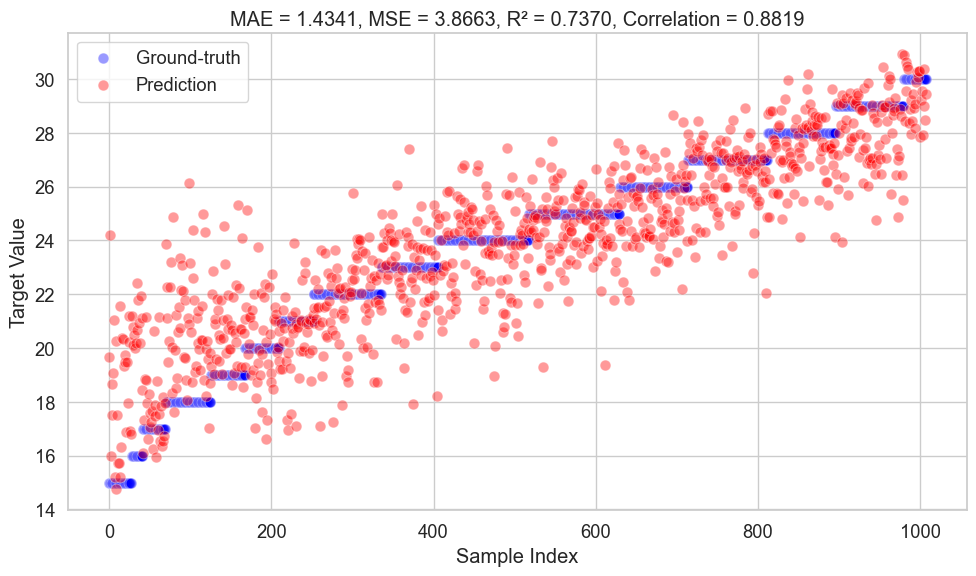

In [21]:
sns.set(style="whitegrid", font_scale=1.2)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=range(len(Y_TRUES)), y=Y_TRUES, label='Ground-truth', color='blue', alpha=0.4, s=60)
sns.scatterplot(x=range(len(Y_PREDS)), y=Y_PREDS, label='Prediction', color='red', alpha=0.4, s=60)

plt.xlabel('Sample Index')
plt.ylabel('Target Value')
plt.title(f"MAE = {mae:.4f}, MSE = {mse:.4f}, R² = {r2:.4f}, Correlation = {corr:.4f}")
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# LightGBM - RFE

In [22]:
x = np.array(sensor)
y = np.array(sis)
p = np.array(participant)

feature_names = sensor.columns.to_list()
# + ['sex', 'age']

selected_features_all_folds = []

Y_TRUES = np.empty([0])
Y_PREDS = np.empty([0])


# cv = LeaveOneOut()
# for fold, (train_idx, test_idx) in enumerate(cv.split(x), start=1):

# cv = LeaveOneGroupOut()
# for fold, (train_idx, test_idx) in enumerate(cv.split(x, y, groups=p), start=1):


In [23]:
cv = KFold(n_splits=5, shuffle=True, random_state=seed)
for fold, (train_idx, test_idx) in enumerate(cv.split(x), start=1):
    


    print(f"Fold {fold}: train={len(train_idx)} test={len(test_idx)}")

    x_train, x_test = x[train_idx], x[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]


    scaler = StandardScaler()
    x_train = scaler.fit_transform(x_train)
    x_test = scaler.transform(x_test)

    normalizer = MinMaxScaler()
    x_train = normalizer.fit_transform(x_train)
    x_test = normalizer.transform(x_test)


    # RFE
    num_features = 24
    model_for_rfe = LGBMRegressor(
        n_estimators=1000,
        learning_rate=.1,
        max_depth=3,
        random_state=seed,
        n_jobs=-1,
        verbose=-1 
    )
    rfe = RFE(estimator=model_for_rfe, n_features_to_select=num_features, step=1)
    rfe.fit(x_train, y_train)

    selected_indices = rfe.get_support(indices=True)
    selected_feature_names = [feature_names[i] for i in selected_indices]
    print(f"Fold {fold} selected features: {selected_feature_names}")
    selected_features_all_folds.extend(selected_feature_names)


    x_train = rfe.transform(x_train)
    x_test = rfe.transform(x_test)

    # ----- LightGBM
    model = LGBMRegressor(
        n_estimators=1000,
        learning_rate=.1,
        max_depth=3,
        random_state=seed,
        n_jobs=-1,
    )
    model.fit(x_train, y_train,
            eval_set=[(x_train, y_train)],
            eval_metric='rmse',
            callbacks=[
                lightgbm.early_stopping(stopping_rounds=100, verbose=False),
                lightgbm.log_evaluation(period=0)  # suppress log output
            ])
    
    y_preds = model.predict(x_test)

    Y_TRUES = np.append(Y_TRUES, y_test)
    Y_PREDS = np.append(Y_PREDS, y_preds)


Fold 1: train=806 test=202
Fold 1 selected features: ['acceleration-mean', 'acceleration-std', 'acceleration-entropy', 'acceleration-skew', 'acceleration-minutes-with-data', 'acceleration-movement-events-00to06', 'acceleration-movement-events-06to12', 'acceleration-movement-events-12to18', 'acceleration-movement-events-18to24', 'acceleration-intradaily-variability', 'heartrate-count', 'heartrate-mean', 'heartrate-std', 'motion-count', 'motion-mean', 'motion-max-timestamp', 'sleep-total', 'sleep-deep', 'sleep-light', 'sleep-rem', 'sleep-snoring', 'sleep-duration-to-sleep', 'sleep-heartrate-max', 'step-max']
Fold 2: train=806 test=202
Fold 2 selected features: ['acceleration-mean', 'acceleration-std', 'acceleration-sum', 'acceleration-entropy', 'acceleration-skew', 'acceleration-minutes-with-data', 'acceleration-movement-events-00to06', 'acceleration-movement-events-06to12', 'acceleration-movement-events-12to18', 'acceleration-movement-events-18to24', 'acceleration-intradaily-variability

In [24]:
indx = Y_TRUES.argsort()
Y_TRUES = Y_TRUES[indx]
Y_PREDS = Y_PREDS[indx]

mae = mean_absolute_error(Y_TRUES, Y_PREDS)
mse = mean_squared_error(Y_TRUES, Y_PREDS)
r2 = r2_score(Y_TRUES, Y_PREDS)
corr, _ = spearmanr(Y_TRUES, Y_PREDS)

results = {
    'mae': f"{mae:.4f}",
    'mse': f"{mse:.4f}",
    'r2_score': f"{r2:.4f}",
    'correlation': f"{corr:.4f}"
}

results = pd.DataFrame([results])
display(results.style.hide(axis='index'))

mae,mse,r2_score,correlation
1.4955,4.1735,0.7161,0.8655


In [25]:
feature_counter = Counter(selected_features_all_folds)
most_common_features = [feat for feat, _ in feature_counter.most_common(num_features)]
print(f"\nMost common {num_features} features across folds: {most_common_features}")

display(x.shape, y.shape, p.shape)


Most common 24 features across folds: ['acceleration-mean', 'acceleration-std', 'acceleration-entropy', 'acceleration-minutes-with-data', 'acceleration-movement-events-00to06', 'acceleration-movement-events-12to18', 'acceleration-movement-events-18to24', 'acceleration-intradaily-variability', 'heartrate-std', 'motion-mean', 'motion-max-timestamp', 'sleep-total', 'sleep-deep', 'sleep-light', 'sleep-rem', 'sleep-snoring', 'sleep-duration-to-sleep', 'acceleration-skew', 'acceleration-movement-events-06to12', 'heartrate-mean', 'motion-count', 'step-max', 'heartrate-count', 'sleep-heartrate-max']


(1008, 46)

(1008,)

(1008,)

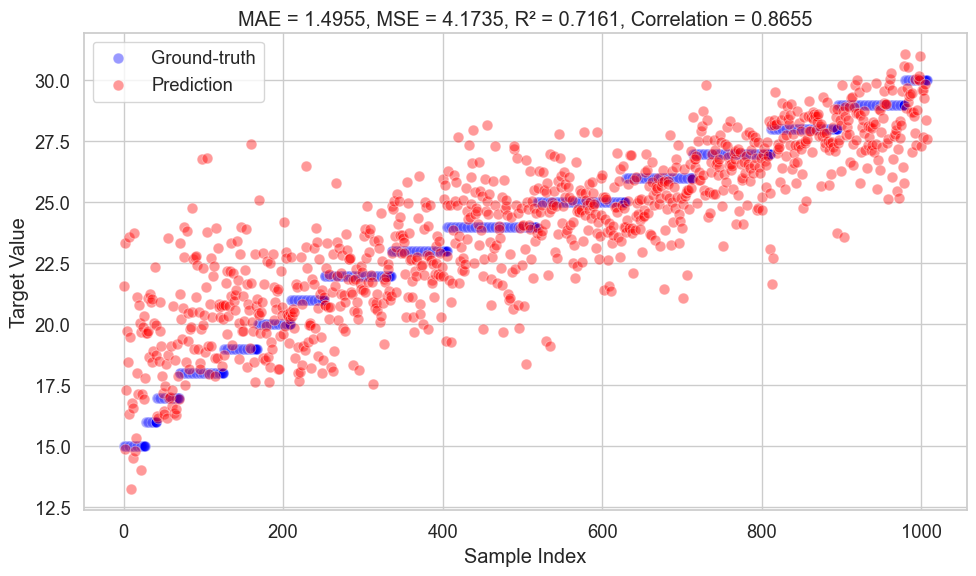

In [26]:
sns.set(style="whitegrid", font_scale=1.2)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=range(len(Y_TRUES)), y=Y_TRUES, label='Ground-truth', color='blue', alpha=0.4, s=60)
sns.scatterplot(x=range(len(Y_PREDS)), y=Y_PREDS, label='Prediction', color='red', alpha=0.4, s=60)

plt.xlabel('Sample Index')
plt.ylabel('Target Value')
plt.title(f"MAE = {mae:.4f}, MSE = {mse:.4f}, R² = {r2:.4f}, Correlation = {corr:.4f}")
plt.legend(loc='best')
plt.tight_layout()
plt.show()